# **Day 99: The Reproducible Research Package**
*Module 13 - Remote Sensing ML and Publication Projects*

Journals (Remote Sensing of Environment, ISPRS, IEEE TGRS, Nature family, Copernicus journals) increasingly require **data and code availability**, and reviewers ask whether the results can be reproduced. A good package lets a stranger regenerate **every number and figure** of the paper with one command, years later.

Today we turn Project 1 (Days 89-91) into such a package, run it end to end **twice**, and verify that the results are identical.

> A reproducible package lets anyone regenerate every number and figure of a paper with one command: code, configuration, pinned software versions, tests and documentation, archived with a DOI.
>
> *Example:* A reviewer downloads the package, runs `python run_all.py`, and gets exactly the accuracy reported in the paper.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, shutil, subprocess, sys, hashlib, platform, time, yaml
from pathlib import Path
import rs_utils as ru
PKG = Path("paper_package_lulc")
if PKG.exists(): shutil.rmtree(PKG)
for sub in ["src", "tests", "docs", "outputs"]: (PKG / sub).mkdir(parents=True, exist_ok=True)

## **1. Package Layout**
```
paper_package_lulc/
  README.md            how to install and run; what each output is
  CITATION.cff         how to cite the code (GitHub and Zenodo read it)
  LICENSE              MIT for code (data: CC-BY-4.0, stated in README)
  environment.yml      exact conda environment (pinned versions)
  config.yaml          every parameter of the study
  run_all.py           ONE command: data -> features -> model -> map -> accuracy -> results.json
  src/                 importable modules (rs_utils.py, lulc_features.py, pipeline.py)
  tests/               fast checks of the scientific core
  docs/                model card, data and code availability statements
  outputs/             generated, never edited by hand (git-ignored; archived with the release)
```
Principles: **raw data are read-only**; everything derived is regenerated by code. Parameters live in the config file, not in the code. Outputs carry provenance.

In [2]:
shutil.copy("rs_utils.py", PKG / "src/rs_utils.py")
shutil.copy("project1_lulc/lulc_features.py", PKG / "src/lulc_features.py")
config = {
    "study": "LULC mapping, Damodar valley (simulated data)",
    "raw_data_dir": "../data/study_area",
    "output_dir": "outputs",
    "seed": 42,
    "classes": ru.LC_CLASSES,
    "model": {"type": "random_forest", "n_estimators": 300, "max_features": "sqrt", "min_samples_leaf": 1},
    "cv": {"block_size_m": 2000, "n_folds": 5},
    "validation": {"target_se_oa": 0.01, "n_rare_class": 75, "user_accuracy_guess": 0.85},
    "pixel_size_m": 20,
}
(PKG / "config.yaml").write_text(yaml.safe_dump(config, sort_keys=False))
print((PKG / "config.yaml").read_text())

study: LULC mapping, Damodar valley (simulated data)
raw_data_dir: ../data/study_area
output_dir: outputs
seed: 42
classes:
- water
- forest
- cropland
- built_up
- mining_bare
- shrub_grass
model:
  type: random_forest
  n_estimators: 300
  max_features: sqrt
  min_samples_leaf: 1
cv:
  block_size_m: 2000
  n_folds: 5
validation:
  target_se_oa: 0.01
  n_rare_class: 75
  user_accuracy_guess: 0.85
pixel_size_m: 20



## **2. The Pipeline Module**
Each step is a small, testable function. The entry point only wires them together and records provenance.

In [3]:
%%writefile paper_package_lulc/src/pipeline.py
"""Project 1 pipeline: training table -> model -> spatial CV -> wall-to-wall map -> stratified accuracy assessment."""
import hashlib, json, platform, time
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import f1_score, accuracy_score
import rs_utils as ru
import lulc_features as lf

def sha256(path, n=16):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:n]

def training_table(raw_dir, F, fnames, transform, block_size):
    pts = gpd.read_file(Path(raw_dir) / "field_points.gpkg")
    r, c = ru.points_to_rowcol(transform, pts.geometry.x.values, pts.geometry.y.values)
    keep = ~pd.DataFrame({"r": r, "c": c}).duplicated().values
    pts, r, c = pts[keep].reset_index(drop=True), r[keep], c[keep]
    X = F[:, r, c].T
    blocks = ru.spatial_blocks(pts.geometry.x.values, pts.geometry.y.values, block_size)
    return X, pts["class_id"].values, blocks, (r, c)

def make_model(cfg):
    m = cfg["model"]
    return RandomForestClassifier(n_estimators=m["n_estimators"], max_features=m["max_features"], min_samples_leaf=m["min_samples_leaf"],
                                  n_jobs=-1, random_state=cfg["seed"])

def spatial_cv(cfg, X, y, blocks):
    pred = cross_val_predict(make_model(cfg), X, y, cv=GroupKFold(cfg["cv"]["n_folds"]), groups=blocks)
    return {"cv_overall_accuracy": float(accuracy_score(y, pred)), "cv_macro_f1": float(f1_score(y, pred, average="macro"))}

def predict_map(model, F):
    K, H, W = F.shape
    out = np.zeros((H, W), np.uint8)
    for r0 in range(0, H, 100):
        out[r0:r0 + 100] = model.predict(F[:, r0:r0 + 100].reshape(K, -1).T).reshape(-1, W)
    return out

def accuracy_assessment(cfg, lc_map, reference_raster):
    K = len(cfg["classes"]); H, W = lc_map.shape; v = cfg["validation"]
    counts = {k: int((lc_map == k).sum()) for k in range(K)}
    Wi = np.array([counts[k] for k in range(K)]) / (H * W); U = np.full(K, v["user_accuracy_guess"])
    n_total = int(np.ceil((np.sum(Wi * np.sqrt(U * (1 - U))) / v["target_se_oa"]) ** 2))
    rare = Wi < 0.05; alloc = np.where(rare, v["n_rare_class"], 0)
    alloc[~rare] = np.round((n_total - alloc.sum()) * Wi[~rare] / Wi[~rare].sum())
    r, c, strata = ru.stratified_random_sample(lc_map, {k: int(a) for k, a in enumerate(alloc)}, seed=cfg["seed"] + 1)
    ref = reference_raster[r, c]                       # in a real study: interpreted reference labels (CSV) instead
    pix_ha = cfg["pixel_size_m"] ** 2 / 1e4
    return ru.olofsson_accuracy(strata, ref, counts, pix_ha, cfg["classes"])

def provenance(cfg, raw_dir, t0):
    import rasterio, geopandas, scipy
    return {"timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()), "runtime_s": round(time.time() - t0, 1),
            "python": platform.python_version(), "platform": platform.platform(),
            "versions": {"numpy": np.__version__, "pandas": pd.__version__, "scikit-learn": sklearn.__version__, "scipy": scipy.__version__,
                         "rasterio": rasterio.__version__, "geopandas": geopandas.__version__},
            "inputs_sha256": {p.name: sha256(p) for p in sorted(Path(raw_dir).glob("*")) if p.suffix in (".tif", ".gpkg") and not p.name.startswith("_")},
            "config_sha256": hashlib.sha256(json.dumps(cfg, sort_keys=True).encode()).hexdigest()[:16]}

Writing paper_package_lulc/src/pipeline.py


In [4]:
%%writefile paper_package_lulc/run_all.py
"""Reproduce every result of the paper:  python run_all.py --config config.yaml"""
import argparse, json, sys, time
from pathlib import Path
import numpy as np
import yaml
sys.path.insert(0, str(Path(__file__).parent / "src"))
import rasterio
import rs_utils as ru
import lulc_features as lf
import pipeline as pl

def main(config_path):
    t0 = time.time()
    root = Path(config_path).parent
    cfg = yaml.safe_load(Path(config_path).read_text())
    np.random.seed(cfg["seed"])
    raw = (root / cfg["raw_data_dir"]).resolve(); out = root / cfg["output_dir"]; out.mkdir(exist_ok=True)
    print("[1/5] features"); F, fnames, groups, gap, profile = lf.build_feature_stack(raw)
    print("[2/5] training table"); X, y, blocks, _ = pl.training_table(raw, F, fnames, profile["transform"], cfg["cv"]["block_size_m"])
    print("[3/5] spatial CV"); cv = pl.spatial_cv(cfg, X, y, blocks)
    print("[4/5] final model and map"); model = pl.make_model(cfg).fit(X, y); lc_map = pl.predict_map(model, F)
    ru.write_geotiff(out / "lulc_map.tif", lc_map, profile["transform"], nodata=255, dtype="uint8", band_names=["land_cover"])
    print("[5/5] accuracy assessment")
    with rasterio.open(raw / "_truth_landcover_SIMULATION_ONLY.tif") as src: reference = src.read(1)
    summary, pmat = pl.accuracy_assessment(cfg, lc_map, reference)
    summary.to_csv(out / "table_accuracy_area.csv", index=False); pmat.to_csv(out / "error_matrix_area_proportions.csv")
    results = {"n_training": int(len(y)), "n_features": len(fnames), **cv,
               "OA": float(summary.attrs["OA"]), "OA_95CI": float(summary.attrs["OA_95CI"]),
               "areas_ha": {r["class"]: [round(float(r["adjusted_area_ha"]), 2), round(float(r["area_95CI_ha"]), 2)] for _, r in summary.iterrows()},
               "map_sha256": pl.hashlib.sha256(lc_map.tobytes()).hexdigest()[:16],
               "provenance": pl.provenance(cfg, raw, t0)}
    (out / "results.json").write_text(json.dumps(results, indent=2))
    print(f"done in {time.time() - t0:.0f} s -> {out / 'results.json'}")

if __name__ == "__main__":
    ap = argparse.ArgumentParser(); ap.add_argument("--config", default=str(Path(__file__).parent / "config.yaml"))
    main(ap.parse_args().config)

Writing paper_package_lulc/run_all.py


## **3. Run It, Twice**
We run the package as a separate process, exactly as a reader would, and then once more. Everything except timestamps and run times must be identical: the CV scores, the map hash, OA and the areas. If not, something is non-deterministic: an unseeded random number generator, iteration order, or multithreaded floating-point reductions in some libraries.

In [5]:
def run_package(tag):
    t0 = time.perf_counter()
    r = subprocess.run([sys.executable, "run_all.py", "--config", "config.yaml"], cwd=PKG, capture_output=True, text=True)
    print(f"--- run {tag}: exit code {r.returncode} in {time.perf_counter() - t0:.0f} s"); print(r.stdout[-600:])
    if r.returncode: print(r.stderr[-2000:])
    res = json.loads((PKG / "outputs/results.json").read_text()); return res

res1 = run_package("A"); res2 = run_package("B")
strip = lambda d: {k: v for k, v in d.items() if k != "provenance"}
print("identical results (excluding provenance timestamps):", strip(res1) == strip(res2))
print(json.dumps(strip(res1), indent=1)[:900])

--- run A: exit code 0 in 7 s
[1/5] features
[2/5] training table
[3/5] spatial CV
[4/5] final model and map
[5/5] accuracy assessment
done in 4 s -> outputs\results.json



--- run B: exit code 0 in 6 s
[1/5] features
[2/5] training table
[3/5] spatial CV
[4/5] final model and map
[5/5] accuracy assessment
done in 5 s -> outputs\results.json

identical results (excluding provenance timestamps): True
{
 "n_training": 598,
 "n_features": 81,
 "cv_overall_accuracy": 0.9096989966555183,
 "cv_macro_f1": 0.9105046692860932,
 "OA": 0.947548192090541,
 "OA_95CI": 0.012749591982947022,
 "areas_ha": {
  "water": [
   94.4,
   5.11
  ],
  "forest": [
   3434.52,
   111.34
  ],
  "cropland": [
   1548.78,
   61.94
  ],
  "built_up": [
   273.67,
   16.58
  ],
  "mining_bare": [
   285.51,
   15.44
  ],
  "shrub_grass": [
   4363.12,
   126.19
  ]
 },
 "map_sha256": "d20d50bf49a8b974"
}


## **4. Tests for the Scientific Core**
Tests protect the parts where a silent bug would change the paper's numbers: the accuracy estimator, sampling, and spatial blocking. Keep them fast (seconds) and based on cases where the right answer is known.

In [6]:
%%writefile paper_package_lulc/tests/test_core.py
"""Run with `pytest -q` or simply `python tests/test_core.py`."""
import sys
from pathlib import Path
import numpy as np
sys.path.insert(0, str(Path(__file__).parents[1] / "src"))
import rs_utils as ru

def test_olofsson_perfect_map():
    rng = np.random.default_rng(0); m = rng.integers(0, 3, 300)
    s, _ = ru.olofsson_accuracy(m, m, {0: 5000, 1: 3000, 2: 2000}, 0.04)
    assert abs(s.attrs["OA"] - 1) < 1e-12 and np.allclose(s["adjusted_area_ha"], s["mapped_area_ha"])

def test_olofsson_area_unbiased():
    rng = np.random.default_rng(1); est = []
    truth = rng.integers(0, 2, 20000); mapped = np.where(rng.random(20000) < 0.1, 1 - truth, truth)
    counts = {0: int((mapped == 0).sum()), 1: int((mapped == 1).sum())}
    for s in range(200):
        idx = np.concatenate([rng.choice(np.flatnonzero(mapped == k), 100, replace=False) for k in (0, 1)])
        est.append(ru.olofsson_accuracy(mapped[idx], truth[idx], counts, 1.0)[0]["adjusted_area_ha"].iloc[1])
    assert abs(np.mean(est) - (truth == 1).sum()) / (truth == 1).sum() < 0.02

def test_stratified_sample_sizes():
    strata = np.repeat(np.arange(3), [100, 50, 10]).reshape(16, 10)
    r, c, lab = ru.stratified_random_sample(strata, {0: 20, 1: 20, 2: 20}, seed=0)
    assert np.bincount(lab).tolist() == [20, 20, 10]                  # capped at the stratum size

def test_spatial_blocks_group_neighbours():
    b = ru.spatial_blocks(np.array([0, 10, 2500]), np.array([0, 10, 0]), 2000)
    assert b[0] == b[1] != b[2]

if __name__ == "__main__":
    for name, fn in list(globals().items()):
        if name.startswith("test_"):
            fn(); print("PASS", name)

Writing paper_package_lulc/tests/test_core.py


In [7]:
r = subprocess.run([sys.executable, "tests/test_core.py"], cwd=PKG, capture_output=True, text=True)
print(r.stdout, r.stderr[-1500:])

PASS test_olofsson_perfect_map
PASS test_olofsson_area_unbiased
PASS test_stratified_sample_sizes
PASS test_spatial_blocks_group_neighbours
 


## **5. Environment, Citation, Licence, README**
Pin the **exact** versions used, generated from the running environment rather than typed by hand.

In [8]:
import sklearn, scipy, rasterio, geopandas, matplotlib, shap, xgboost, lightgbm, torch
versions = {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__,
            "scikit-learn": sklearn.__version__, "matplotlib": matplotlib.__version__, "rasterio": rasterio.__version__,
            "geopandas": geopandas.__version__, "pyyaml": yaml.__version__, "shap": shap.__version__, "xgboost": xgboost.__version__,
            "lightgbm": lightgbm.__version__, "pytorch": torch.__version__.split("+")[0]}
env = {"name": "lulc-paper", "channels": ["conda-forge"],
       "dependencies": [f"python={versions['python']}"] + [f"{k}={v}" for k, v in versions.items() if k not in ("python", "pytorch", "shap", "xgboost", "lightgbm")]
                       + [{"pip": [f"shap=={versions['shap']}", f"xgboost=={versions['xgboost']}", f"lightgbm=={versions['lightgbm']}"]}]}
(PKG / "environment.yml").write_text(yaml.safe_dump(env, sort_keys=False))
(PKG / "requirements.txt").write_text("\n".join(f"{k}=={v}" for k, v in versions.items() if k not in ("python", "pytorch")) + "\n")
(PKG / ".gitignore").write_text("outputs/\n__pycache__/\n*.pyc\n.ipynb_checkpoints/\n*.tif\n!docs/*.tif\n")
(PKG / "LICENSE").write_text("MIT License\n\nCopyright (c) 2026 <Author Names>\n\nPermission is hereby granted, free of charge, to any person obtaining a copy of this "
                             "software ... (full MIT text: https://opensource.org/license/mit)\n")
(PKG / "CITATION.cff").write_text("""cff-version: 1.2.0
message: "If you use this software, please cite it and the associated article."
title: "Code for: Multi-season Sentinel-1/2 land-cover mapping in the Damodar valley"
authors:
  - family-names: "<Surname>"
    given-names: "<Given name>"
    affiliation: "<Department>, <Institution>"
    orcid: "https://orcid.org/0000-0000-0000-0000"
version: 1.0.0
date-released: 2026-10-02
license: MIT
repository-code: "https://github.com/<user>/<repo>"
identifiers:
  - type: doi
    value: "10.5281/zenodo.<record-id>"
""")
print((PKG / "environment.yml").read_text())

name: lulc-paper
channels:
- conda-forge
dependencies:
- python=3.12.14
- numpy=2.5.3
- pandas=3.0.6
- scipy=1.18.1
- scikit-learn=1.9.1
- matplotlib=3.11.2
- rasterio=1.5.2
- geopandas=1.2.0
- pyyaml=6.0.3
- pip:
  - shap==0.52.0
  - xgboost==3.4.1
  - lightgbm==4.7.0



In [9]:
res = res1
readme = f"""# Code and data for: Multi-season Sentinel-1/2 land-cover mapping in the Damodar valley

This repository reproduces all results of the article *<title>* (<journal>, <year>, doi:<...>).

## Quick start
```bash
conda env create -f environment.yml
conda activate lulc-paper
python run_all.py --config config.yaml       # ~1 minute; writes outputs/
python tests/test_core.py                    # or: pytest -q
```

## What `run_all.py` produces
| File | Content | Paper item |
|---|---|---|
| `outputs/lulc_map.tif` | land-cover map, uint8, EPSG:32645, 20 m | Fig. 6 |
| `outputs/table_accuracy_area.csv` | UA, PA with 95% CI, bias-corrected areas | Table 4 |
| `outputs/error_matrix_area_proportions.csv` | error matrix in area proportions | Table 4b |
| `outputs/results.json` | all headline numbers + provenance (versions, input hashes) | text |

Headline results of the archived run: spatial-CV macro F1 = {res['cv_macro_f1']:.3f}; map overall accuracy = {res['OA']:.3f} +/- {res['OA_95CI']:.3f} (95% CI).

## Data
Input rasters (`data/study_area/*.tif`) and field points (`field_points.gpkg`) are archived at Zenodo (doi:10.5281/zenodo.<record-id>) under CC-BY-4.0.
Sentinel-1/2 data: Copernicus Sentinel data 2024, accessed via Google Earth Engine (collections listed in `docs/data_availability.md`).

## Structure
`config.yaml` (all parameters) - `run_all.py` (entry point) - `src/` (modules) - `tests/` - `docs/` (model card, availability statements)

## Licence
Code: MIT. Data: CC-BY-4.0. Please cite using `CITATION.cff`.
"""
(PKG / "README.md").write_text(readme); print(readme[:700])

# Code and data for: Multi-season Sentinel-1/2 land-cover mapping in the Damodar valley

This repository reproduces all results of the article *<title>* (<journal>, <year>, doi:<...>).

## Quick start
```bash
conda env create -f environment.yml
conda activate lulc-paper
python run_all.py --config config.yaml       # ~1 minute; writes outputs/
python tests/test_core.py                    # or: pytest -q
```

## What `run_all.py` produces
| File | Content | Paper item |
|---|---|---|
| `outputs/lulc_map.tif` | land-cover map, uint8, EPSG:32645, 20 m | Fig. 6 |
| `outputs/table_accuracy_area.csv` | UA, PA with 95% CI, bias-corrected areas | Table 4 |
| `outputs/error_matrix_area_proportions.csv


## **6. Model Card and Availability Statements**
A **model card** (Mitchell et al. 2019) documents what a model is for, how it was evaluated, and where it should not be used. For RS products, add the spatial and temporal domain and the area of applicability. We generate it from `results.json`, so it can never disagree with the results.

In [10]:
areas_txt = "\n".join(f"| {k} | {v[0]:,.1f} | +/- {v[1]:,.1f} |" for k, v in res["areas_ha"].items())
card = f"""# Model card: LULC random forest, Damodar valley 2024

**Model**: random forest ({config['model']['n_estimators']} trees, max_features={config['model']['max_features']}), scikit-learn {res['provenance']['versions']['scikit-learn']}.
**Inputs**: {res['n_features']} features from seasonal Sentinel-2 composites, Sentinel-1 VV/VH, texture, terrain (20 m, EPSG:32645).
**Classes**: {', '.join(config['classes'])}.
**Intended use**: land-cover mapping and area estimation in the study area for 2024. **Not intended** for other regions or years without
re-validation, nor for parcel-level decisions (pixel accuracy varies, see the confidence layer).

## Training data
{res['n_training']} field points, stratified random sampling on a prior map, GPS (~8 m), ~3-7% label noise (estimated in QC).

## Evaluation
- Spatial {config['cv']['n_folds']}-fold block CV ({config['cv']['block_size_m']} m blocks): OA {res['cv_overall_accuracy']:.3f}, macro F1 {res['cv_macro_f1']:.3f}.
- Independent stratified random validation sample (Olofsson et al. 2014): **OA {res['OA']:.3f} +/- {res['OA_95CI']:.3f}** (95% CI).

| class | adjusted area (ha) | 95% CI |
|---|---|---|
{areas_txt}

## Limitations
Spectrally similar classes (forest / shrub, cropland / shrub) are confused at boundaries; thin linear features are under-mapped at 20 m.
Predictions outside the area of applicability (computed as in Day 91) are extrapolations; check the AOA before applying the model elsewhere.

## Provenance
Inputs SHA-256: {', '.join(f'{k}: {v}' for k, v in res['provenance']['inputs_sha256'].items())}; config hash {res['provenance']['config_sha256']}.
"""
(PKG / "docs/model_card.md").write_text(card)
(PKG / "docs/data_availability.md").write_text("""## Data availability statement (template)
Sentinel-1 GRD and Sentinel-2 L2A data are freely available from the Copernicus Data Space Ecosystem and Google Earth Engine
(collections COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED, COPERNICUS/S1_GRD; Copernicus DEM GLO-30).
The field reference data, the training table, the final map and the validation sample are available at Zenodo (doi:10.5281/zenodo.<id>)
under CC-BY-4.0. Exact field coordinates of private land are generalised to 100 m for privacy; precise locations are available on request.

## Code availability statement (template)
All code is available at https://github.com/<user>/<repo> and archived at Zenodo (doi:10.5281/zenodo.<id>, release v1.0.0).
`run_all.py` reproduces all tables and figures.
""")
print(card[:1200])

# Model card: LULC random forest, Damodar valley 2024

**Model**: random forest (300 trees, max_features=sqrt), scikit-learn 1.9.1.
**Inputs**: 81 features from seasonal Sentinel-2 composites, Sentinel-1 VV/VH, texture, terrain (20 m, EPSG:32645).
**Classes**: water, forest, cropland, built_up, mining_bare, shrub_grass.
**Intended use**: land-cover mapping and area estimation in the study area for 2024. **Not intended** for other regions or years without
re-validation, nor for parcel-level decisions (pixel accuracy varies, see the confidence layer).

## Training data
598 field points, stratified random sampling on a prior map, GPS (~8 m), ~3-7% label noise (estimated in QC).

## Evaluation
- Spatial 5-fold block CV (2000 m blocks): OA 0.910, macro F1 0.911.
- Independent stratified random validation sample (Olofsson et al. 2014): **OA 0.948 +/- 0.013** (95% CI).

| class | adjusted area (ha) | 95% CI |
|---|---|---|
| water | 94.4 | +/- 5.1 |
| forest | 3,434.5 | +/- 111.3 |
| cropland

## **7. Archiving: GitHub + Zenodo**
1. `git init`, commit the package (not `outputs/`, not large rasters). Use `.gitignore`.
2. Push to GitHub; connect the repository to **Zenodo** (zenodo.org -> GitHub -> enable the repository).
3. Create a **release** (`v1.0.0`). Zenodo archives it and mints a **DOI**, which we cite in the paper. Upload the data and outputs as a separate Zenodo record (large files are fine there).
4. After the review: release `v1.1.0` with the revisions. The concept DOI always points to the latest version.

```bash
git init && git add . && git commit -m "Code for LULC paper, submitted version"
git tag v1.0.0 && git remote add origin https://github.com/<user>/<repo>.git && git push -u origin main --tags
```

**Docker** (optional, for full OS-level reproducibility):
```dockerfile
FROM mambaorg/micromamba:1.5.8
COPY environment.yml /tmp/env.yml
RUN micromamba env create -f /tmp/env.yml && micromamba clean -a -y
COPY . /work
WORKDIR /work
CMD ["micromamba", "run", "-n", "lulc-paper", "python", "run_all.py"]
```

In [11]:
print("Package contents:")
for p in sorted(PKG.rglob("*")):
    if p.is_file() and "__pycache__" not in str(p): print(f"  {p.relative_to(PKG).as_posix():<45} {p.stat().st_size / 1e3:>8.1f} kB")

Package contents:
  .gitignore                                         0.1 kB
  CITATION.cff                                       0.5 kB
  config.yaml                                        0.4 kB
  docs/data_availability.md                          0.8 kB
  docs/model_card.md                                 1.7 kB
  environment.yml                                    0.3 kB
  LICENSE                                            0.2 kB
  outputs/error_matrix_area_proportions.csv          0.5 kB
  outputs/lulc_map.tif                              24.8 kB
  outputs/results.json                               1.3 kB
  outputs/table_accuracy_area.csv                    0.8 kB
  README.md                                          1.5 kB
  requirements.txt                                   0.2 kB
  run_all.py                                         2.3 kB
  src/lulc_features.py                               3.2 kB
  src/pipeline.py                                    3.5 kB
  src/rs_utils.py     

# **Part 2: Going Deeper**

## **8. Publication-Quality Figures**
| Rule | Practice |
|---|---|
| Size | Design at the final size: single column ~85-90 mm, double column ~170-180 mm wide |
| Fonts | 7-9 pt at final size; the same font family everywhere |
| Format | Vector (PDF / SVG / EPS) for plots; TIFF or PNG at 300-600 dpi for maps and images |
| Colour | Colour-blind-safe palettes (viridis, cividis, ColorBrewer); never encode meaning by red vs green alone |
| Maps | Scale bar, north arrow, coordinates or grid, legend, CRS in the caption |

**Check our palette for colour-vision deficiency.** About 8% of men have red-green deficiency. Simulate deuteranopia with the Machado et al. (2009) matrix:

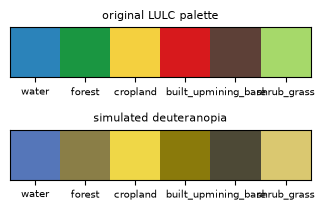

least distinguishable pair under deuteranopia: cropland vs shrub_grass (distance 0.189); separate them by lightness, or add a hatched / labelled legend


In [12]:
from matplotlib.colors import to_rgb
M_DEUT = np.array([[0.367, 0.861, -0.228], [0.280, 0.673, 0.047], [-0.012, 0.043, 0.969]])
def to_linear(c): c = np.asarray(c); return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)
def to_srgb(c): c = np.clip(c, 0, 1); return np.where(c <= 0.0031308, 12.92 * c, 1.055 * c ** (1 / 2.4) - 0.055)
def simulate_deuteranopia(rgb): return to_srgb(to_linear(np.asarray(rgb)) @ M_DEUT.T)

orig = np.array([to_rgb(c) for c in ru.LC_COLORS]); sim = simulate_deuteranopia(orig)
fig, axes = plt.subplots(2, 1, figsize=(8, 2.2))
for ax, cols, t in [(axes[0], orig, "original LULC palette"), (axes[1], sim, "simulated deuteranopia")]:
    ax.imshow(cols[None]); ax.set_yticks([]); ax.set_xticks(range(len(cols)), ru.LC_CLASSES, fontsize=7); ax.set_title(t, fontsize=8)
plt.tight_layout(); plt.show()
d = np.linalg.norm(sim[:, None] - sim[None], axis=-1); np.fill_diagonal(d, np.inf)
i, j = np.unravel_index(d.argmin(), d.shape)
print(f"least distinguishable pair under deuteranopia: {ru.LC_CLASSES[i]} vs {ru.LC_CLASSES[j]} (distance {d[i, j]:.3f}); "
      "separate them by lightness, or add a hatched / labelled legend")

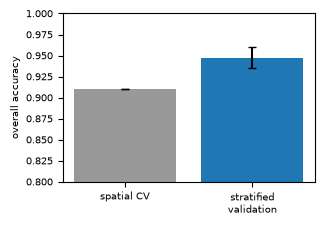

saved vector PDF and 600-dpi PNG at the final print size


In [13]:
fig, ax = plt.subplots(figsize=(85 / 25.4, 60 / 25.4))                          # single-column figure, 85 x 60 mm
with plt.rc_context({"font.size": 7}):
    oa = [res["cv_overall_accuracy"], res["OA"]]
    ax.bar(["spatial CV", "stratified\nvalidation"], oa, yerr=[0, res["OA_95CI"]], capsize=3, color=["0.6", "tab:blue"])
    ax.set_ylim(0.8, 1); ax.set_ylabel("overall accuracy", fontsize=7); ax.tick_params(labelsize=7)
fig.tight_layout(); fig.savefig(PKG / "docs/fig_example_single_column.pdf"); fig.savefig(PKG / "docs/fig_example_single_column.png", dpi=600); plt.show()
print("saved vector PDF and 600-dpi PNG at the final print size")

## **Practice Problems**
1. Change `seed` in `config.yaml` to 7 and rerun the package. Which numbers change, and by how much? What does this say about reporting a single run?
2. Add a test checking that `indices()` returns NDVI = 0 when B8 = B4.
3. Add a `--quick` option to `run_all.py` that uses 50 trees (for continuous-integration tests), and make sure it does not overwrite the archived results.
4. *(Advanced)* Write a GitHub Actions workflow (`.github/workflows/tests.yml`) that creates the environment and runs the tests on every push.

In [14]:
# Solution 1
cfg2 = yaml.safe_load((PKG / "config.yaml").read_text()); cfg2["seed"] = 7; cfg2["output_dir"] = "outputs_seed7"
(PKG / "config_seed7.yaml").write_text(yaml.safe_dump(cfg2, sort_keys=False))
r = subprocess.run([sys.executable, "run_all.py", "--config", "config_seed7.yaml"], cwd=PKG, capture_output=True, text=True)
res7 = json.loads((PKG / "outputs_seed7/results.json").read_text())
for k in ["cv_overall_accuracy", "cv_macro_f1", "OA"]:
    print(f"{k:<22}: seed 42 {res1[k]:.4f} | seed 7 {res7[k]:.4f} | diff {res7[k] - res1[k]:+.4f}")
print("The validation sample also changes with the seed: report CIs, and never pick the 'best' seed.")

cv_overall_accuracy   : seed 42 0.9097 | seed 7 0.9080 | diff -0.0017
cv_macro_f1           : seed 42 0.9105 | seed 7 0.9089 | diff -0.0016
OA                    : seed 42 0.9475 | seed 7 0.9447 | diff -0.0029
The validation sample also changes with the seed: report CIs, and never pick the 'best' seed.


In [15]:
# Solution 2
test2 = '''

def test_ndvi_zero_when_equal():
    b = {k: np.full((2, 2), 0.2) for k in ["B2", "B3", "B4", "B5", "B8", "B8A", "B11"]}
    assert np.allclose(ru.indices(b)["NDVI"], 0)
'''
src = (PKG / "tests/test_core.py").read_text().replace('\n\nif __name__ == "__main__":', test2 + '\n\nif __name__ == "__main__":')
(PKG / "tests/test_core.py").write_text(src)
print(subprocess.run([sys.executable, "tests/test_core.py"], cwd=PKG, capture_output=True, text=True).stdout)

PASS test_olofsson_perfect_map
PASS test_olofsson_area_unbiased
PASS test_stratified_sample_sizes
PASS test_spatial_blocks_group_neighbours
PASS test_ndvi_zero_when_equal



**Solution 3 (sketch):** add `ap.add_argument("--quick", action="store_true")`. If it is set, use `cfg["model"]["n_estimators"] = 50` and `cfg["output_dir"] = "outputs_quick"`.

**Solution 4:**
```yaml
name: tests
on: [push, pull_request]
jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: mamba-org/setup-micromamba@v1
        with: {environment-file: environment.yml}
      - run: python tests/test_core.py
        shell: bash -el {0}
```

## **Key References**
- Wilkinson, M. D. et al. (2016). The FAIR Guiding Principles for scientific data management and stewardship. *Scientific Data*, 3, 160018.
- Mitchell, M. et al. (2019). Model cards for model reporting. *Proceedings of FAT* 2019*, 220-229.
- Gebru, T. et al. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86-92.
- Wilson, G. et al. (2017). Good enough practices in scientific computing. *PLOS Computational Biology*, 13(6), e1005510.
- Peng, R. D. (2011). Reproducible research in computational science. *Science*, 334(6060), 1226-1227.
- Machado, G. M., Oliveira, M. M., & Fernandes, L. A. F. (2009). A physiologically-based model for simulation of color vision deficiency. *IEEE Transactions on Visualization and Computer Graphics*, 15(6), 1291-1298.
- Crameri, F., Shephard, G. E., & Heron, P. J. (2020). The misuse of colour in science communication. *Nature Communications*, 11, 5444.